<a href="https://colab.research.google.com/github/Bharati-png/apexplanet-data-analytics/blob/main/notebooks/task1_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Hello ApexPlanet")

Hello ApexPlanet


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/leonism/sample-superstore/master/data/SampleSuperstore.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

HTTPError: HTTP Error 404: Not Found

In [3]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [6]:
f.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [10]:
df.drop(columns="Row ID").duplicated().sum()

np.int64(1)

In [11]:
before = df.shape[0]
df = df.drop_duplicates(subset=[c for c in df.columns if c != "Row ID"])
after = df.shape[0]
print("Rows before:", before)
print("Rows after:", after)
print("Removed:", before - after)

Rows before: 9994
Rows after: 9993
Removed: 1


In [12]:
df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [14]:
for col in ["Sales", "Quantity", "Discount", "Profit"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "-> outliers:", count)

Sales -> outliers: 1167
Quantity -> outliers: 170
Discount -> outliers: 856
Profit -> outliers: 1881


In [15]:
for col in ["Sales", "Profit", "Quantity"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col + "_capped"] = df[col].clip(lower, upper)

df[["Sales", "Sales_capped", "Profit", "Profit_capped"]].describe()

,Sales,Sales_capped,Profit,Profit_capped
count,9993.000000,9993.000000,9993.000000,9993.000000
mean,229.852846,140.266986,28.660971,16.070737
std,623.276074,168.806787,234.271476,29.485177
min,0.444000,0.444000,-6599.978000,-39.718500
25%,17.280000,17.280000,1.731000,1.731000
50%,54.480000,54.480000,8.671000,8.671000
75%,209.940000,209.940000,29.364000,29.364000
max,22638.480000,498.930000,8399.976000,70.813500


In [16]:
df.to_csv("superstore_cleaned.csv", index=False)
print("Saved!", df.shape)

Saved! (9993, 24)


In [17]:
from google.colab import files
files.download("superstore_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

NameError: name 'df' is not defined

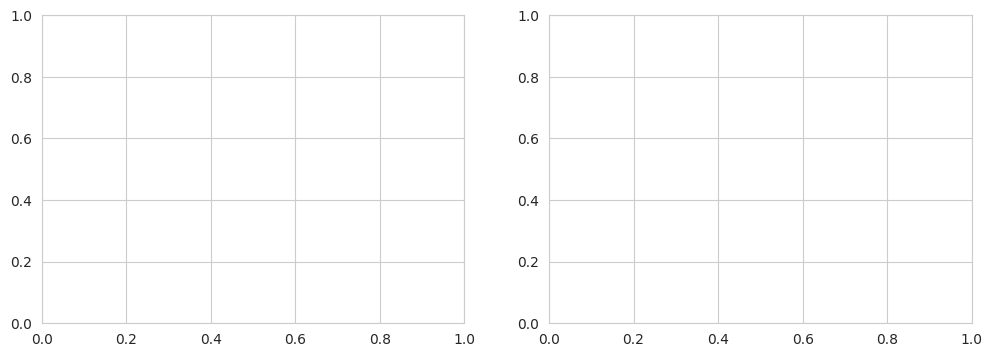

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Sales_capped"], bins=30, ax=axes[0])
axes[0].set_title("Sales Distribution (capped)")
sns.histplot(df["Profit_capped"], bins=30, ax=axes[1])
axes[1].set_title("Profit Distribution (capped)")
plt.tight_layout()
plt.show()

In [2]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Category", y="Profit_capped", data=df)
plt.title("Profit by Category")
plt.show()

NameError: name 'df' is not defined

<Figure size 800x500 with 0 Axes>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("superstore_cleaned.csv", parse_dates=["Order Date", "Ship Date"])
print(df.shape)
df.head(3)

(9993, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Sales_capped,Profit_capped,Quantity_capped
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,261.96,41.9136,2.0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,498.93,70.8135,3.0
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,14.62,6.8714,2.0


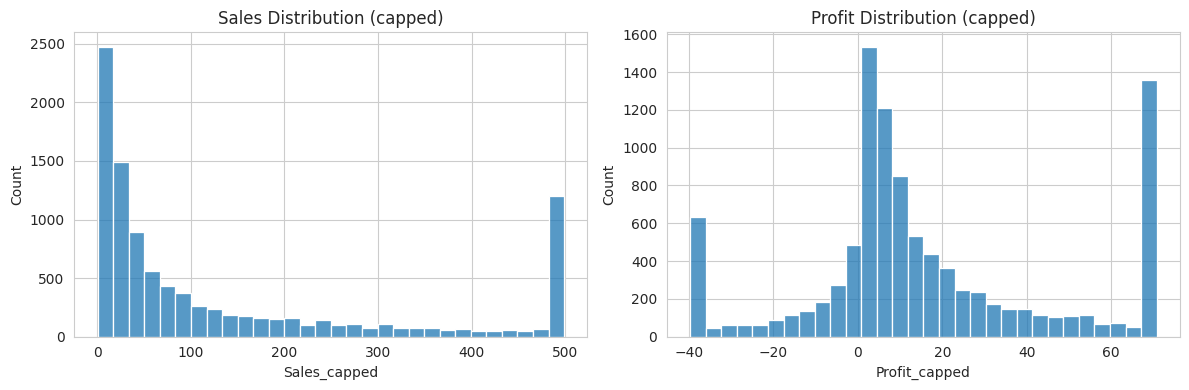

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Sales_capped"], bins=30, ax=axes[0])
axes[0].set_title("Sales Distribution (capped)")
sns.histplot(df["Profit_capped"], bins=30, ax=axes[1])
axes[1].set_title("Profit Distribution (capped)")
plt.tight_layout()
plt.show()

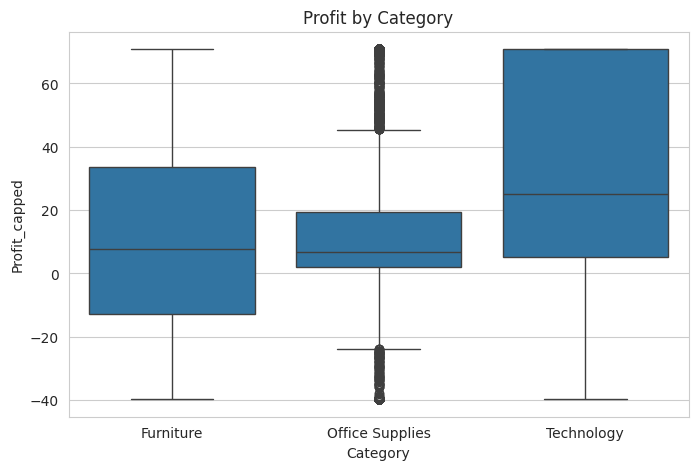

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Category", y="Profit_capped", data=df)
plt.title("Profit by Category")
plt.show()

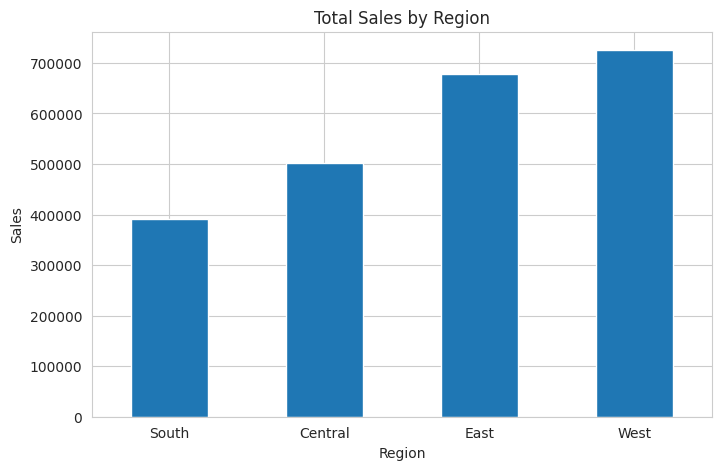

In [6]:
plt.figure(figsize=(8, 5))
df.groupby("Region")["Sales"].sum().sort_values().plot(kind="bar")
plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

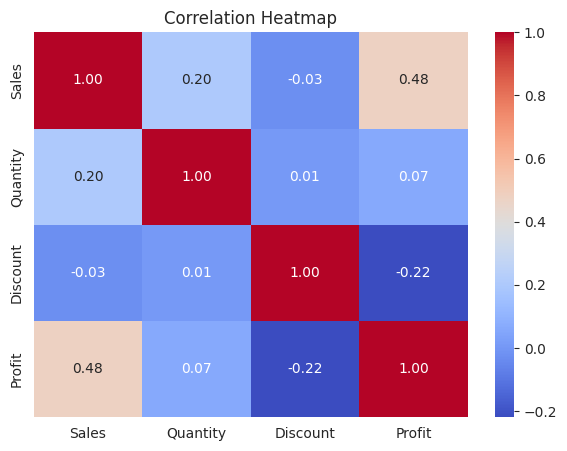

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[["Sales", "Quantity", "Discount", "Profit"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

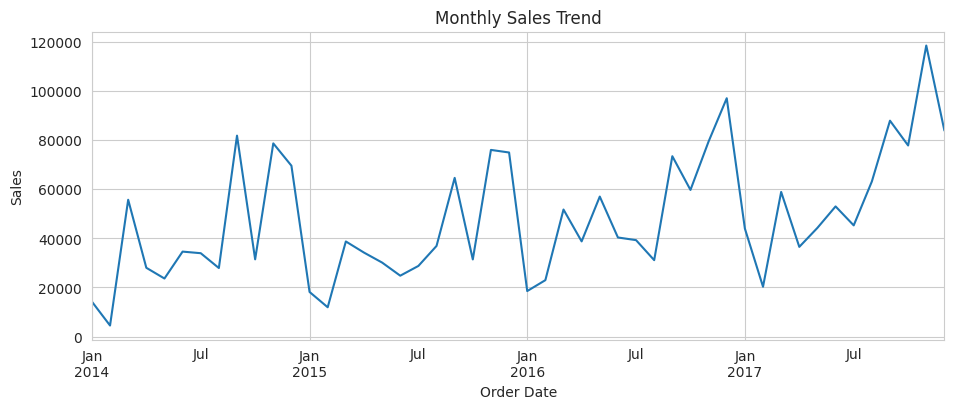

In [8]:
monthly = df.set_index("Order Date")["Sales"].resample("ME").sum()

plt.figure(figsize=(11, 4))
monthly.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

## Key Insights

1. **Data quality:** The dataset had no missing values. One hidden duplicate row was found and removed after ignoring Row ID, leaving 9,993 rows.
2. **Outliers:** Sales and Profit have many extreme values (about 12% and 19% of rows by the IQR method). Most orders are small, and a few very large orders pull the average up. These were capped, not deleted, so real business data was kept.
3. **Discounts hurt profit:** Discount and Profit have a negative correlation (-0.22), so heavier discounting goes with lower profit. Sales and Profit are moderately positively correlated (0.48).
4. **Category and region:** Technology has the highest profit among the three categories. The West region has the highest total sales and the South the lowest.
5. **Seasonality and growth:** Monthly sales rise from 2014 to 2017 and peak near the end of each year, with the highest peak at the end of 2017. Sales are weakest in the early months of each year.

In [9]:
print(df.groupby("Category")["Profit"].sum().round(0))
print(df.groupby("Region")["Sales"].sum().round(0))

Category
Furniture           18463.0
Office Supplies    122491.0
Technology         145455.0
Name: Profit, dtype: float64
Region
Central    501240.0
East       678500.0
South      391722.0
West       725458.0
Name: Sales, dtype: float64
